<a href="https://colab.research.google.com/github/nurgissas/ML-personal-learning/blob/main/day04_overfitting_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4 — See overfitting with your own eyes + regularization
**Deliverable checklist — your finished notebook must contain:**
1. ✅ Plot showing degree 1 / 4 / 15 polynomial fits (under/good/over)
2. ✅ Train vs test MSE for each degree
3. ✅ Ridge with 3 alphas compared via 5-fold CV
4. ✅ A small results table + 3-sentence conclusion

> Work top to bottom. **EXAMPLE** cells are done for you — copy the pattern. **TODO** cells are yours. Struggle 30+ min before opening the ✅ Solution sketch in the study app.

**📚 Coding references** *(theory is the videos' job; these teach the code)*: [sklearn's own under/overfitting example](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html) — nearly the same exercise, official code · [cross-validation guide](https://scikit-learn.org/stable/modules/cross_validation.html)

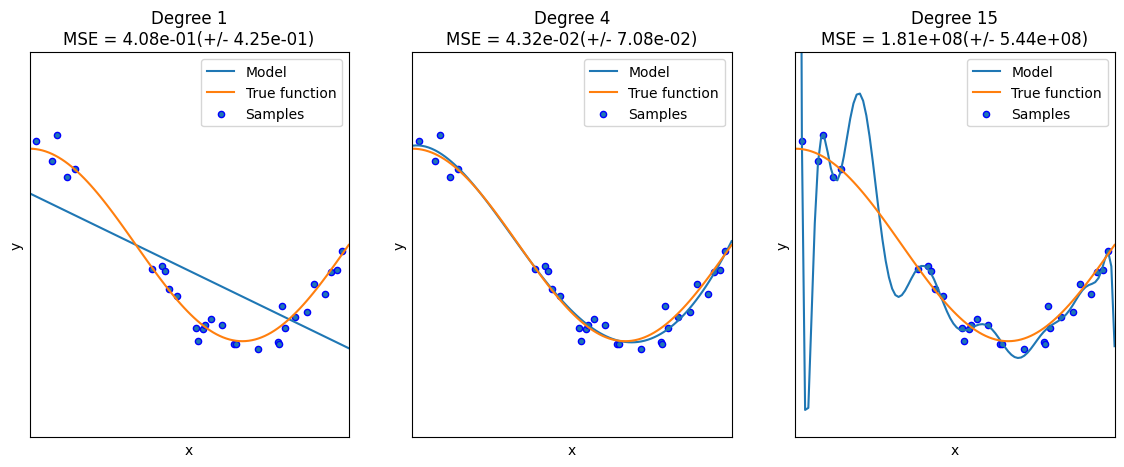

In [14]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


def true_fun(X):
    return np.cos(1.5 * np.pi * X)


np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]
# degrees = [1, 4, 10, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
            ("linear_regression", linear_regression),
        ]
    )
    pipeline.fit(X[:, np.newaxis], y)

    # Evaluate the models using crossvalidation
    scores = cross_val_score(
        pipeline, X[:, np.newaxis], y, scoring="neg_mean_squared_error", cv=10
    )

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor="b", s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(
        "Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
            degrees[i], -scores.mean(), scores.std()
        )
    )
plt.show()

In [40]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score

In [41]:
# EXAMPLE — wiggly fake data
np.random.seed(1)
x = np.sort(np.random.rand(30))
y = np.sin(1.5*np.pi*x) + np.random.randn(30)*0.15
Xtr, Xte, ytr, yte = train_test_split(x.reshape(-1,1), y, test_size=0.4, random_state=0)

MSE: degrees: 1 | 0.221
MSE: degrees: 4 | 0.02
MSE: degrees: 15 | 4501.363


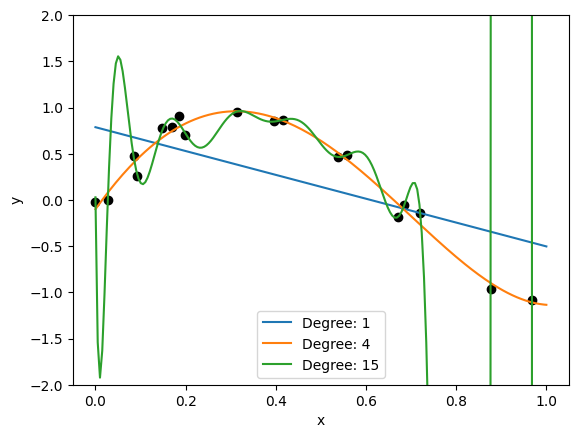

In [37]:
# TODO — for degree in [1, 4, 15]:
#   plot its curve
#   print train MSE and test MSE
# Expect: deg 1 = both bad (underfit) · deg 4 = both good · deg 15 = train tiny, test huge (OVERFIT)
grid = np.linspace(0,1,200).reshape(-1, 1)
plt.scatter(Xtr, ytr, c="k")
degrees = [1, 4, 15]
for degree in degrees:
  polyn = PolynomialFeatures(degree=degree, include_bias=False)
  reg = LinearRegression()
  model = make_pipeline(polyn, reg).fit(Xtr, ytr)
  plt.plot(grid, model.predict(grid), label=f"Degree: {degree}")
  print(f"MSE: degrees: {degree} | {str(round(np.mean((model.predict(Xte)-yte)**2), 3))}")
plt.ylim(-2,2)
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

**TODO — your words:** which degree overfits and how do you KNOW from the two numbers (not the picture)?

In [48]:
# TODO — Ridge on California Housing with 5-fold CV
# from sklearn.datasets import fetch_california_housing
# for alpha in [0.01, 1, 100]:
#     scores = cross_val_score(Ridge(alpha=alpha), X, y, cv=5)
#     print(alpha, scores.mean().round(4), scores.std().round(4))
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = housing.data
y = housing.target
for alpha in [0.01, 1, 100]:
  scores = cross_val_score(Ridge(alpha=alpha), X, y, cv=5)
  print(f"Alpha: {alpha}, Mean: {scores.mean().round(4)}, st: {scores.std().round(4)}")

Alpha: 0.01, Mean: 0.553, st: 0.0617
Alpha: 1, Mean: 0.553, st: 0.0617
Alpha: 100, Mean: 0.5534, st: 0.0632


**TODO — results table + conclusion (3 sentences):**

| alpha | mean CV score | std |
|---|---|---|
| 0.01 |0.553 |0.0617 |
| 1 |0.553 |0.0617 |
| 100 | 0.5534| 0.0632|

0.01 and 1 alphas: R-squared is 0.553 with sd of 0.0617, meaning model explains about 55.3% of variance in the target.

Conclusion: for California housing dataset and chosen alpha values Ridge reg effect is minimal, since R-squared scores are similar across alphas.

## ✅ Expected outputs checkpoint
Before shipping, verify you see roughly this — if not, debug before moving on:
- Degree 1: train & test MSE both high · degree 4: both low · degree 15: train ≈ 0, test **exploded** (often 10-1000×)
- Ridge: `cross_val_score` returns **R² by default** (~0.5-0.6 here); alpha=100 should be visibly worse than alpha≈1
- If degree 15 doesn't explode, check you're printing TEST error, not train

## Ship it
Colab: **File → Save a copy in GitHub** → pick your `ml-30-days` repo → commit.
Then open the study app, say the 🎯 criteria out loud, and tick the homework box. 🎉